In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Inflation and Policy Rates: A Study of Time-Lagged Relationships
---
# Introduction

Monetary policy is often analyzed using the Taylor rule, which describes how policy rates respond to inflation [1]. Instead of estimating a full reaction function, this project examines whether a simpler statistical relationship between lagged policy rates and inflation can be identified using linear regression. The objective is to explore how the association between monetary policy and inflation varies across different time lags, and whether simple models can capture patterns consistent with monetary transmission mechanisms. The analysis focuses interpretation rather than prediction.

<br>

[1]. https://www.riksbank.se/sv/press-och-publicerat/nyheter-och-pressmeddelanden/nyheter/2017/dagens-penningpolitik-ar-i-linje-med-taylor-regeln/

#1. Retrieving and Cleaning
---
1.1. Collect the inflation data from SCB using an API.

In [2]:
import requests
import pandas as pd

'''Both URL and Payload is available at SCB (below the table):
https://www.statistikdatabasen.scb.se/pxweb/sv/ssd/START__PR__PR0101__PR0101G/KPIF/table/tableViewLayout1/?loadedQueryId=160586&timeType=from&timeValue=1987M01
'''

SCB_url = "https://api.scb.se/OV0104/v1/doris/sv/ssd/START/PR/PR0101/PR0101G/KPIF"

payload = {
    "query": [
        {
            "code": "ContentsCode",
            "selection": {
                "filter": "item",
                "values": ["PR0101F1"]  # KPIF
            }}],
    "response": {
        "format": "json" }
}

# API request
response = requests.post(SCB_url, json=payload)
api = response.json()


Converting fetched data to a panda dataframe.

In [3]:
''' Understand the format of the API '''
#print(api)
#print(type(api))
inflation_data = api['data'][12::] #[12::] för att de första 12 elementen hade inflationsvärdet [..]. Med hjälp av list slicing tar jag enkelt bort dem.
#print(inflation_data)
#print(type(inflation_data[0]))
#print(inflation_data[12])

''' Create a dataframe '''
inflation_df = pd.DataFrame(inflation_data)
#print(inflation_df)
inflation_df.rename(columns={'key': 'date', 'values': 'inflation'}, inplace=True)

''' Some adjustments (data come as one-element lists, so we must un-pack them)'''
inflation_df['date'] = inflation_df['date'].str[0]
inflation_df['inflation'] = inflation_df['inflation'].str[0]

''' Converting columns to the correct datatype '''
inflation_df['date'] = pd.to_datetime(inflation_df['date'], format= '%YM%m') # Before the format is [yyyy'M'mm], ex. [1988M01]
inflation_df['inflation'] = inflation_df['inflation'].astype(float) # Convert inflation values from strings to float
inflation_df = inflation_df.reset_index(drop=True) #Use default index

print(inflation_df)



          date  inflation
0   1988-01-01        4.5
1   1988-02-01        4.9
2   1988-03-01        5.2
3   1988-04-01        5.9
4   1988-05-01        6.0
..         ...        ...
450 2025-07-01        3.0
451 2025-08-01        3.2
452 2025-09-01        3.1
453 2025-10-01        3.1
454 2025-11-01        2.3

[455 rows x 2 columns]


1.2. Collecting the policy rate data. This data is instead imported from an Excel document available at the Swedish Central Bank (Riksbanken) website:
https://www.riksbank.se/sv/statistik/rantor-och-valutakurser/styrranta-in--och-utlaningsranta/

In [4]:
policy_rate_df = pd.read_excel('/content/drive/MyDrive/LINC/styrrantan-effektiv.xlsx')
#print(policy_rate_df)
#print(type(policy_rate_df))
#print(type(policy_rate_df['Unnamed: 0']))
'''Adjusting formats and renaming columns'''
policy_rate_df['Unnamed: 0'] = pd.to_datetime(policy_rate_df['Unnamed: 0'], format='%Y-%m-%d')
policy_rate_df.rename(columns={'Unnamed: 0': 'date', 'Styrräntan per förändring (effektiv)': 'policy rate'}, inplace=True)
print(policy_rate_df)


          date  policy rate
0   2006-01-26         1.75
1   2006-03-02         2.00
2   2006-05-03         2.00
3   2006-06-22         2.25
4   2006-09-07         2.50
..         ...          ...
120 2025-06-25         2.00
121 2025-08-27         2.00
122 2025-10-01         1.75
123 2025-11-12         1.75
124 2026-01-07         1.75

[125 rows x 2 columns]


1.3. Cleaning
Ensuring timeorder using pandas built-in functions - important since we are dealing with time-series.

In [5]:
inflation_df = inflation_df.sort_values('date')
policy_rate_df = policy_rate_df.sort_values('date')

One issue is the difference in "frequency of data". Inflation is updated monthly whereas the policy rate is provided closer to every other month (exactly 8 updates/yr). However, since the policy rate is constant for the period in-between updates and an approximation of monthly rates can be made by simply filling out missing months the with the value of the period.

In [6]:
'''Add a new column (called month) to each dataframe with only month (and year)'''
inflation_df['month'] = inflation_df['date'].dt.to_period('M')
policy_rate_df['month'] = policy_rate_df['date'].dt.to_period('M')
#print(inflation_df)
#print(policy_rate_df)

'''Create a separate dataframe with only month and policy rate'''
policy_rate_manad = policy_rate_df[['month', 'policy rate']]
#print(policy_rate_manad)

print(inflation_df['month'].is_unique) #check for duplicates, if true => no duplicates :)

'''Merge the secondary policy rate dataframe with the primary inflation dataframe'''
policy_rate_manad = inflation_df[['month']].merge(policy_rate_manad, on='month', how='left')

'''...and fill in missing (monthly) values with the previous value'''
policy_rate_manad['policy rate'] = policy_rate_manad['policy rate'].ffill()
print(policy_rate_manad)




True
       month  policy rate
0    1988-01          NaN
1    1988-02          NaN
2    1988-03          NaN
3    1988-04          NaN
4    1988-05          NaN
..       ...          ...
451  2025-07         2.00
452  2025-08         2.00
453  2025-09         2.00
454  2025-10         1.75
455  2025-11         1.75

[456 rows x 2 columns]


Then create one large dataframe containing both inflation and policy rate.

In [7]:
total_df = inflation_df.merge(policy_rate_manad, on='month', how='inner')
total_df = total_df[['date', 'inflation', 'policy rate']].sort_values('date').reset_index(drop=True)
print(total_df.head(), '\n', total_df.tail())

        date  inflation  policy rate
0 1988-01-01        4.5          NaN
1 1988-02-01        4.9          NaN
2 1988-03-01        5.2          NaN
3 1988-04-01        5.9          NaN
4 1988-05-01        6.0          NaN 
           date  inflation  policy rate
451 2025-07-01        3.0         2.00
452 2025-08-01        3.2         2.00
453 2025-09-01        3.1         2.00
454 2025-10-01        3.1         1.75
455 2025-11-01        2.3         1.75


Since the policy rate only goes back to 2006 - there's several data points with no existing values (NaN). The extent of the study is therefor limited to the time period of the policy rate - and NaN-entries are dropped.


In [8]:
total_df = total_df.dropna().reset_index(drop=True)

In [9]:
'''240 datapoints with inflation AND policy rate remain after dropping NaN'''
print(total_df.shape, '\n', total_df.head(), '\n' ,total_df.tail())


(240, 3) 
         date  inflation  policy rate
0 2006-01-01        1.2         1.75
1 2006-02-01        1.1         1.75
2 2006-03-01        1.5         2.00
3 2006-04-01        1.8         2.00
4 2006-05-01        1.9         2.00 
           date  inflation  policy rate
235 2025-07-01        3.0         2.00
236 2025-08-01        3.2         2.00
237 2025-09-01        3.1         2.00
238 2025-10-01        3.1         1.75
239 2025-11-01        2.3         1.75


#2. Data Analysis
---

Visual inspection of data. A plot of inflation and policy rate over time, 2006/01-2025/11, as well as a scatterplot of inflation against policy rate.

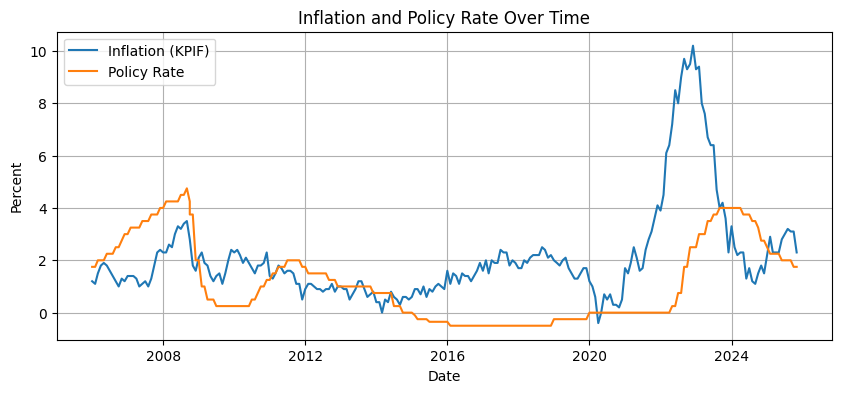

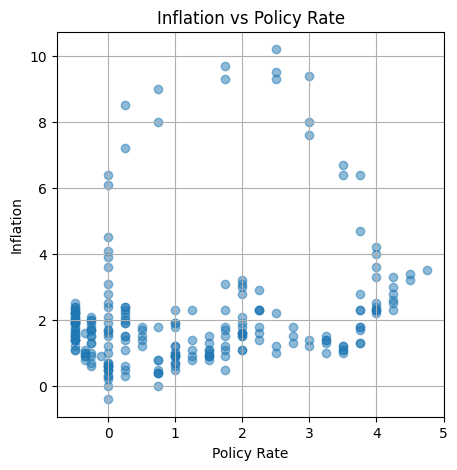

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(total_df['date'], total_df['inflation'], label='Inflation (KPIF)')
plt.plot(total_df['date'], total_df['policy rate'], label='Policy Rate')
plt.xlabel('Date')
plt.ylabel('Percent')
plt.title('Inflation and Policy Rate Over Time')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(total_df['policy rate'], total_df['inflation'], alpha=0.5)
plt.xlabel('Policy Rate')
plt.ylabel('Inflation')
plt.title('Inflation vs Policy Rate')
plt.grid(True)
plt.show()

Neither plot indicate any major correlation. The latter (scatter plot) suggest a weak positive correlation - particularly if one looks beyond the economic turbulence of early 2020s that left a trail of really high inflation values. The slight postive correlation is confirmed by computation below. A relatively low correlation is likely expected since the inflation is affected by many factors besides policy rate, like global prices and market expectations.

In [11]:
corr = total_df[['inflation','policy rate']].corr()
print(corr)


             inflation  policy rate
inflation     1.000000     0.250193
policy rate   0.250193     1.000000


The policy rate is used by the central bank to influence inflation and the overall economy. The effect of the rate is delayed, as it takes time for financial markets, firms and households to adjust. It typically takes 1-2 years for changes in the policy rate to have an impact [2]. Therefore, we expect the effects of the policy rate to appear with a time (transmission) lag, and we are primarily interested in examining the correlation at different lags. A higher policy rate is expected to dampen inflation; consequently, we anticipate a negative correlation. <br> <br> [2]. https://www.sparbankentanum.se/privat/tips-och-rad/vad-ar-styrranta.html

In [12]:
'''The policy rate is shifted backward by k periods to model transmission lags.'''

for k in [1, 3, 6, 12, 24, 48]:
    total_df[f'policy rate lag{k}'] = total_df['policy rate'].shift(k)

Notice that the dataset is reduced when lags are created.

In [13]:
df_lag = total_df.dropna().reset_index(drop=True)
print(df_lag.shape)

(192, 9)


In [14]:
print(df_lag)

          date  inflation  policy rate  policy rate lag1  policy rate lag3  \
0   2009-12-01        2.4         0.25              0.25              0.25   
1   2010-01-01        2.3         0.25              0.25              0.25   
2   2010-02-01        2.4         0.25              0.25              0.25   
3   2010-03-01        2.2         0.25              0.25              0.25   
4   2010-04-01        1.9         0.25              0.25              0.25   
..         ...        ...          ...               ...               ...   
187 2025-07-01        3.0         2.00              2.00              2.25   
188 2025-08-01        3.2         2.00              2.00              2.25   
189 2025-09-01        3.1         2.00              2.00              2.00   
190 2025-10-01        3.1         1.75              2.00              2.00   
191 2025-11-01        2.3         1.75              1.75              2.00   

     policy rate lag6  policy rate lag12  policy rate lag24  po

A visual inspection of inflation vs lagged policy rate.

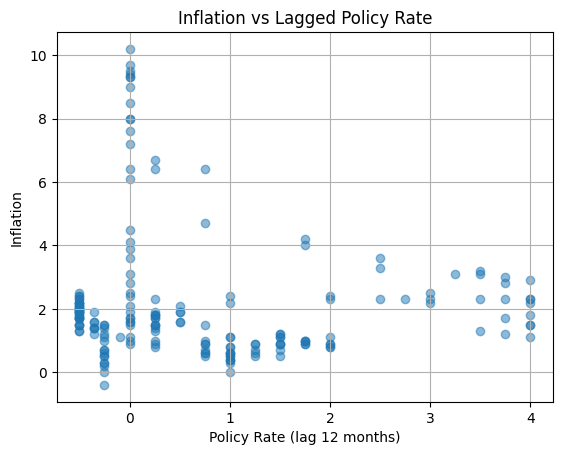

In [15]:
plt.scatter(df_lag['policy rate lag12'], df_lag['inflation'], alpha=0.5)
plt.xlabel('Policy Rate (lag 12 months)')
plt.ylabel('Inflation')
plt.title('Inflation vs Lagged Policy Rate')
plt.grid(True)
plt.show()


A weak negative correlation is observed for a 12 month lag.  



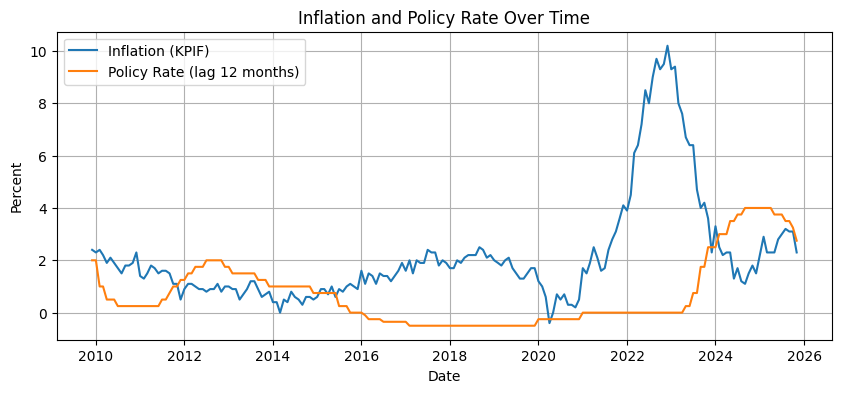

In [17]:
plt.figure(figsize=(10,4))
plt.plot(df_lag['date'], df_lag['inflation'], label='Inflation (KPIF)')
plt.plot(df_lag['date'], df_lag['policy rate lag12'], label='Policy Rate (lag 12 months)')
plt.xlabel('Date')
plt.ylabel('Percent')
plt.title('Inflation and Policy Rate Over Time')
plt.legend()
plt.grid(True)
plt.show()

Finally, we examine the Pearson correlation between inflation and lagged policy rates and find that correlation decrease as the lags increase and turn negative at longer horizons, suggesting a delayed dampening effect of monetary policy. However, at very long lags, such as 48 months, the strong negative correlation is more likely to reflect long-run macroeconomic cycles and regime shifts rather than a direct causal effect of monetary policy.

In [19]:
#cols = ['policy rate', 'policy rate_lag1', 'policy rate_lag3', 'policy rate_lag6', 'policy rate_lag-1']
cols = ['policy rate', 'policy rate lag1', 'policy rate lag3', 'policy rate lag6', 'policy rate lag12','policy rate lag24', 'policy rate lag48']
print(df_lag[['inflation'] + cols].corr())


                   inflation  policy rate  policy rate lag1  policy rate lag3  \
inflation           1.000000     0.329747          0.279126          0.179948   
policy rate         0.329747     1.000000          0.993500          0.973036   
policy rate lag1    0.279126     0.993500          1.000000          0.986315   
policy rate lag3    0.179948     0.973036          0.986315          1.000000   
policy rate lag6    0.051079     0.911617          0.935061          0.972910   
policy rate lag12  -0.092608     0.712546          0.747616          0.814353   
policy rate lag24  -0.134161     0.188602          0.203276          0.237372   
policy rate lag48  -0.352882    -0.002249          0.005689          0.019659   

                   policy rate lag6  policy rate lag12  policy rate lag24  \
inflation                  0.051079          -0.092608          -0.134161   
policy rate                0.911617           0.712546           0.188602   
policy rate lag1           0.935061    

# 3. Model Building and Evalutation

---

Given a continuous dependent variable and the exploratory indication of lag-dependent relationships, we employ linear regression models with lagged policy rates to quantify the association between monetary policy and inflation. <br>

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Model A:  i_t = β_0 ​+ β_1​r_(t−24) ​+ ε_t​

---
=> Can inflation today be explained by policy rate two years ago?

In [21]:
X_A = df_lag[['policy rate lag24']]
y = df_lag['inflation']

model_A = LinearRegression().fit(X_A, y)
y_pred_A = model_A.predict(X_A)

print("Model A")
print("Coefficient (β_1):", model_A.coef_[0])
print("Intercept (β_0):", model_A.intercept_)
print("R²:", r2_score(y, y_pred_A))
print("MSE:", mean_squared_error(y, y_pred_A))


Model A
Coefficient (β_1): -0.20229134408024255
Intercept (β_0): 2.33398136285683
R²: 0.017999121075438995
MSE: 4.221605369193807


The model give a low R², which suggest limited explanatory power. This could be reasonable given the multifactor nature of inflation. Since the analysis is not focused on prediction, the mean squared error is not a central evaluation metric.

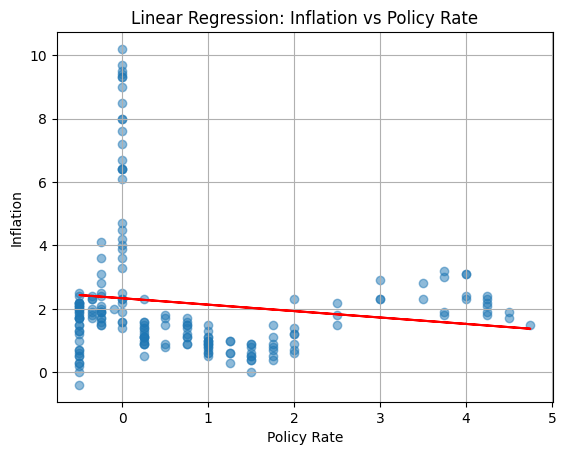

In [22]:
import matplotlib.pyplot as plt
import numpy as np

x = df_lag['policy rate lag24']
y_line = model_A.intercept_ + model_A.coef_[0] * x

plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_line, color='red')
plt.xlabel('Policy Rate')
plt.ylabel('Inflation')
plt.title('Linear Regression: Inflation vs Policy Rate')
plt.grid(True)
plt.show()


### Model B: i_t = β_0 + β_1·r_(t-3) + β_2·r_(t-12) + β_3·r_(t-24) + ε_t
---
=> Multiple time lags

In [23]:
X_B = df_lag[['policy rate lag3', 'policy rate lag12','policy rate lag24']]
model_B = LinearRegression().fit(X_B, y)
y_pred_B = model_B.predict(X_B)

print("Model B")
print("Coefficient:", model_B.coef_)
print("Intercept:", model_B.intercept_)
print("R²:", r2_score(y, y_pred_B))
print("MSE:", mean_squared_error(y, y_pred_B))

Model B
Coefficient: [ 1.2937917  -1.330227    0.17713586]
Intercept: 1.9894738339837683
R²: 0.2102859550868854
MSE: 3.3949674829049488


A suspisiously large increase in R2-score is observed for model B. Policy rates are strongly autocorrelated. So a check for multicolliniarity before interpretation is necessary. Generally, a VIF between 1 and 3 is considered low, between 3 and 5 moderate, and 5 or above high [3].

[3]. https://www.investopedia.com/terms/v/variance-inflation-factor.asp

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_lag[['policy rate lag3', 'policy rate lag12', 'policy rate lag24']]
X = X.dropna()

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,policy rate lag3,4.360538
1,policy rate lag12,6.161378
2,policy rate lag24,1.953190


A high VIF is seen particularly for the 12 month time lag (for natural reason). So coefficients should be carefully interpreted. Instead the variable with the highest multicollinarity is dropped, resulting in a new model C.

### Model C: β_0 + β_1·r_(t-3) + β_2·r_(t-24) + ε_t

----
=> Model C captures short and long term reactions.

In [25]:
X_C = df_lag[['policy rate lag3', 'policy rate lag24']]
model_C = LinearRegression().fit(X_C, y)

In [26]:
y_pred_C = model_C.predict(X_C)

print("Model C")
print("Coefficient:", model_C.coef_)
print("Intercept:", model_C.intercept_)
print("R²:", r2_score(y, y_pred_C))
print("MSE:", mean_squared_error(y, y_pred_C))

Model C
Coefficient: [ 0.35043657 -0.28262228]
Intercept: 2.118164030597841
R²: 0.06553426474718993
MSE: 4.017252580864501


Before interpretation a quick look at multicolinearity,

In [27]:
X = df_lag[['policy rate lag3', 'policy rate lag24']]
X = X.dropna()

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,policy rate lag3,1.2216
1,policy rate lag24,1.2216


VIF values indicate low correlation between independent variables of the model. Regarding the performance of the model the R2-score increased about three times to A, making it the best model. For model C about 6-7 % of variation in inflation can be explained by the model. This is not a particularly strong explanatory power. Although a low R2-score might be expected for macrodata.

### A final comment:
---

The results indicate a weak but negative relationship between lagged policy rates and inflation, with the strongest association observed at longer lags. This is consistent with the delayed transmission of monetary policy.

# 4. Dashboard and Visualisation
---

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


In [29]:
fig_ts = go.Figure()

fig_ts.add_trace(go.Scatter(
    x=df_lag.index,
    y=df_lag['inflation'],
    mode='lines',
    name='Inflation'
))

fig_ts.add_trace(go.Scatter(
    x=df_lag.index,
    y=df_lag['policy rate'],
    mode='lines',
    name='Policy Rate',
    yaxis='y2'
))

fig_ts.update_layout(
    title='Inflation and Policy Rate Over Time',
    yaxis=dict(title='Inflation'),
    yaxis2=dict(title='Policy Rate', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)


In [31]:
lags = [0, 3, 6, 12, 24]
correlations = [
    df_lag['inflation'].corr(df_lag[f'policy rate lag{lag}']) if lag > 0
    else df_lag['inflation'].corr(df_lag['policy rate'])
    for lag in lags
]

fig_corr = go.Figure()

fig_corr.add_trace(go.Scatter(
    x=lags,
    y=correlations,
    mode='lines+markers'
))

fig_corr.update_layout(
    title='Correlation Between Inflation and Lagged Policy Rate',
    xaxis_title='Lag (months)',
    yaxis_title='Correlation'
)


In [32]:
x = df_lag['policy rate lag24']
y = df_lag['inflation']

y_line = model_C.intercept_ + model_C.coef_[1] * x  # coef_[1] = lag24

fig_reg = go.Figure()

fig_reg.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='markers',
    name='Data',
    opacity=0.5
))

fig_reg.add_trace(go.Scatter(
    x=x,
    y=y_line,
    mode='lines',
    name='Regression Line'
))

fig_reg.update_layout(
    title='Inflation vs Policy Rate (24-month lag)',
    xaxis_title='Policy Rate (lag 24)',
    yaxis_title='Inflation'
)


In [34]:
results_df = pd.DataFrame({
    'Metric': ['Intercept', 'Coeff (lag 3 months)', 'Coeff (lag 24 months)', 'R²', 'MSE'],
    'Value': [
        round(model_C.intercept_, 3),
        round(model_C.coef_[0], 3),
        round(model_C.coef_[1], 3),
        round(r2_score(y, model_C.predict(df_lag[['policy rate lag3','policy rate lag24']])), 3),
        round(mean_squared_error(y, model_C.predict(df_lag[['policy rate lag3','policy rate lag24']])), 2)
    ]
})


fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(results_df.columns)),
    cells=dict(values=[results_df[col] for col in results_df.columns])
)])

fig_table.update_layout(title='Model C – Regression Results')



In [35]:
from plotly.subplots import make_subplots

# Gör fyra subplots
dashboard = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"colspan": 2}, None],
        [{"colspan": 2}, None],
        [{"type": "xy"}, {"type": "domain"}]  # viktigt: domain för table
    ],
    subplot_titles=[
        "Time Series",
        "Correlation vs Lag",
        "Regression (lag 24)",
        "Model Results"
    ]
)

# Lägg till
for trace in fig_ts.data:
    dashboard.add_trace(trace, row=1, col=1)

for trace in fig_corr.data:
    dashboard.add_trace(trace, row=2, col=1)

for trace in fig_reg.data:
    dashboard.add_trace(trace, row=3, col=1)

for trace in fig_table.data:
    dashboard.add_trace(trace, row=3, col=2)

# Lite layout

dashboard.update_layout(height=900, title_text="Monetary Policy and Inflation – Interactive Analysis")
dashboard.update_xaxes(title_text="Time", row=1, col=1)
dashboard.update_yaxes(title_text="Inflation", row=1, col=1)
dashboard.update_yaxes(title_text="Policy Rate", row=1, col=1, secondary_y=True)

dashboard.update_xaxes(title_text="Lag (months)", row=2, col=1)
dashboard.update_yaxes(title_text="Correlation", row=2, col=1)

dashboard.update_xaxes(title_text="Policy Rate (lag 24 months)", row=3, col=1)
dashboard.update_yaxes(title_text="Inflation", row=3, col=1)


In [ ]:
#Skapa HTML

filename = "inflation_policy_dashboard.html"
dashboard.write_html(filename)

from google.colab import files
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>